#  **Where Art Meets Intelligence**

<center>
<img src="https://api.nga.gov/iiif/10b60beb-8b9f-480b-8734-7f00b20284d8/full/!200,200/0/default.jpg"">
</center>

Art is more than pigment on canvas or ink on paper—it is a language of expression shaped by culture, history, and human imagination. From the textured depth of oil paintings to the fluid spontaneity of watercolors, every artistic medium carries its own story, technique, and identity.

In the digital age, art is no longer confined to galleries and museums. Vast collections are being archived, analyzed, and explored using data. Each artwork is accompanied by rich contextual information—titles that hint at meaning, descriptions that narrate intent, and metadata that anchors it in time and space.

This project sits at the intersection of creativity and computation. By leveraging machine learning, we aim to decode patterns hidden within artistic data and automatically identify the medium of an artwork. What may seem like a simple classification task is, in reality, a deeper exploration of how language, structure, and visual cues reflect artistic techniques.

Can a model distinguish the delicate transparency of watercolor from the layered richness of oil paint? Can it learn the subtle signals embedded in words and forms?

Let’s find out.....

# **Problem Framing**

Target:
Predict artistic medium (multi-class classification)

Inputs:

- Text → titles, descriptions, captions
- Structured → year, dimensions, category
- Optional → image URL

This is essentially:

$$f(text,metadata,image)→medium$$

# **About Dataset**

**Columns**

- id — Unique identifier for each artwork
- t — Title of the artwork
- txt — Detailed textual description
- cap — Caption or short summary
- img — Image URL (can be used for vision models)
- y — Target label (only present in train.csv)

**Metadata Columns**
- y0 — Start year of the artwork

- y1 — End year of the artwork

- dt — Display date (text format)

- dim — Dimensions (text format)

- width, height — Numeric size attributes (if available)

- cat — Category or classification label

- tp — Data type

- tag — Tags or keywords associated with the artwork

- note — Additional notes or remarks

# **Libraries**

In [134]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

import seaborn as sns 
import pandas as pd 

import warnings
warnings.filterwarnings('ignore')

In [135]:
plt.style.use('dark_background')

plt.rcParams.update({
    # Figure
    "figure.figsize": (10, 6),
    "figure.dpi": 120,

    # Axes
    "axes.facecolor": "#111111",
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.grid": True,

    # Grid
    "grid.color": "#444444",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,

    # Ticks
    "xtick.color": "white",
    "ytick.color": "white",

    # Legend
    "legend.facecolor": "#111111",
    "legend.edgecolor": "white",
    "legend.fontsize": 10,

    # Lines
    "lines.linewidth": 2,
    "lines.markersize": 6,

    # Font
    "font.size": 11,
    "font.family":      "DejaVu Sans",
})

# **Data Loading And Basic Overview**

In [136]:
df = pd.read_csv('train_data.csv')
df.drop(columns=['id', 'Unnamed: 0', 'uuid', 'acc_id', 'iiifurl', 'lastdetectedmodification', 'iiifthumburl'], inplace=True)
df.head()

,acc,loc,t,dt,y0,y1,ts,dim,inscription,markings,...,tp,ord,txt,tag,note,eff,cat,img,cap,y
0,1,NaN,Beach Scene at Trouville,1863,1863.0,1863.0,1851 to 1875,overall: 34.8 x 57.5 cm (13 11/16 x 22 5/8 in....,lower left: E. Boudin 63,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,painted surface|Beach|Trouville|French Paintin...,https://api.nga.gov/iiif/85f2142e-1b34-4e75-a0...,A oil on wood artwork titled 'Beach Scene at T...,4
1,1,NaN,Playing Cards,15th century,1400.0,1499.0,1300 to 1400,sheet: 29.1 × 43.6 cm (11 7/16 × 17 3/16 in.),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Lombard,https://api.nga.gov/iiif/717a802a-4449-4cf6-8b...,A print artwork titled 'Playing Cards' by Unkn...,5
2,1,NaN,Agriculture,1939,1939.0,1939.0,1926 to 1950,Image: 274 x 246 mm\r\nSheet: 357 x 303 mm,"Inscribed: Within the print: lower right, HELE...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://api.nga.gov/iiif/5b8cada2-0d67-45bb-96...,A print artwork titled 'Agriculture' by Unknow...,5
3,1,NaN,"Burning of Old South Church, Bath, Maine",c. 1854,1854.0,1854.0,1851 to 1875,overall: 46.5 x 61.8 cm (18 5/16 x 24 5/16 in....,NaN,NaN,...,previous_attribution,1.0,American 19th Century,American 19th Century,Attribution at time of gift,NaN,"American|Bath, ME|Old South Church|American Na...",https://api.nga.gov/iiif/c8befcd8-4237-4652-ba...,A oil on canvas artwork titled 'Burning of Old...,2
4,1,13181.0,Le gourmet,1901,1901.0,1901.0,1901 to 1925,overall: 92.8 x 68.3 cm (36 9/16 x 26 7/8 in.)...,upper left: Picasso,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Eating|Twentieth and Twenty-first Century Pain...,https://api.nga.gov/iiif/e19a2b28-639c-4d6a-84...,A oil on canvas artwork titled 'Le gourmet' by...,2


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   acc                          4000 non-null   int64  
 1   loc                          667 non-null    float64
 2   t                            4000 non-null   object 
 3   dt                           3746 non-null   object 
 4   y0                           3999 non-null   float64
 5   y1                           3999 non-null   float64
 6   ts                           3999 non-null   object 
 7   dim                          3768 non-null   object 
 8   inscription                  2333 non-null   object 
 9   markings                     166 non-null    object 
 10  attributioninverted          4000 non-null   object 
 11  attribution                  4000 non-null   object 
 12  provenancetext               3416 non-null   object 
 13  creditline        

In [138]:
df.iloc[0]

acc                                                                            1
loc                                                                          NaN
t                                                       Beach Scene at Trouville
dt                                                                          1863
y0                                                                        1863.0
y1                                                                        1863.0
ts                                                                  1851 to 1875
dim                            overall: 34.8 x 57.5 cm (13 11/16 x 22 5/8 in....
inscription                                             lower left: E. Boudin 63
markings                                                                     NaN
attributioninverted                                               Boudin, Eugène
attribution                                                        Eugène Boudin
provenancetext              

# **Data Cleaning**

In [139]:
# extra columns 
cols_to_exclude = ['t', 'txt', 'cap', 'img', 'y0', 'y1', 'dt', 'dim', 'width', 'height', 'cat', 'tp', 'tag', 'note', 'y']
df_other = df[[col for col in df.columns if col not in cols_to_exclude]]
df_other.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   acc                          4000 non-null   int64  
 1   loc                          667 non-null    float64
 2   ts                           3999 non-null   object 
 3   inscription                  2333 non-null   object 
 4   markings                     166 non-null    object 
 5   attributioninverted          4000 non-null   object 
 6   attribution                  4000 non-null   object 
 7   provenancetext               3416 non-null   object 
 8   creditline                   4000 non-null   object 
 9   classification               4000 non-null   object 
 10  subclassification            107 non-null    object 
 11  visualbrowserclassification  4000 non-null   object 
 12  parentid                     310 non-null    float64
 13  isvirtual         

In [140]:
df_other.iloc[0]

acc                                                                            1
loc                                                                          NaN
ts                                                                  1851 to 1875
inscription                                             lower left: E. Boudin 63
markings                                                                     NaN
attributioninverted                                               Boudin, Eugène
attribution                                                        Eugène Boudin
provenancetext                 Charles de Bériot, Paris; (his sale, Hôtel Dro...
creditline                                Collection of Mr. and Mrs. Paul Mellon
classification                                                          Painting
subclassification                                                            NaN
visualbrowserclassification                                             painting
parentid                    

## **Columns with missing values**

In [141]:
print(df.isnull().sum()[lambda x: x > 0].sort_values(ascending=False))

volume               3994
eff                  3903
subclassification    3893
customprinturl       3850
watermarks           3839
markings             3834
parentid             3690
portfolio            3626
note                 3618
series               3615
tag                  3572
tp                   3497
ord                  3497
txt                  3497
loc                  3333
assistivetext        3283
maxpixels            2692
inscription          1667
provenancetext        584
element               264
dimensiontype         264
dimension             264
unitname              264
dt                    254
dim                   232
cat                   145
wikidataid            113
ts                      1
y1                      1
y0                      1
dtype: int64


In [142]:
# 1. Removing Unnecessary columns
cols = [
    'acc', 'created', 'modified', 'wikidataid', 'customprinturl', 
    'isvirtual', 'viewtype',  'sequence', 'parentid', 'loc', 
    'subclassification', 'volume', 'eff', 'markings', 'watermarks',
    'assistivetext', 'portfolio', 'series', 'maxpixels', 
    'tp', 'ord', 'attributioninverted', 'depictstmsobjectid', 'ts',
    'dt', 'dim', 'provenancetext', 'element', 'dimensiontype', 'unitname'
]

df.drop(columns=cols, inplace=True)

In [143]:
def handle_missing(data):

    # 2. Handle the 1 missing row in y0/y1
    data["y0"].fillna(data["y0"].median(), inplace=True)
    data["y1"].fillna(data["y1"].median(), inplace=True)

    # 3. Numeric dimension — fill with per-class median
    data["dimension"] = data.groupby("y")["dimension"].transform(
        lambda x: x.fillna(x.median())
    )
    data["dimension"].fillna(data["dimension"].median(), inplace=True)  # fallback

    #  4. Engineer numeric features
    data["aspect_ratio"] = data["width"] / data["height"]
    data["date_range"]   = data["y1"] - data["y0"]
    data["decade"]       = (data["y0"] // 10 * 10).astype(int)

    # 5. Sparse text — add presence flags, fill empty
    for col in ["txt", "tag", "note", "inscription"]:
        data[f"has_{col}"] = data[col].notna().astype(int)
        data[col].fillna("", inplace=True)

    # 6. cat — fill missing with empty string
    data["cat"].fillna("", inplace=True)

    # ── 7. Build a combined text column for TF-IDF / embeddings ──
    data["text_combined"] = (
        data["t"].fillna("") + " " +
        data["attribution"].fillna("") + " " +
        data["classification"].fillna("") + " " +
        data["cat"] + " " +
        data["txt"] + " " +
        data["tag"]
    )

In [144]:
df.isnull().sum()

t                                 0
y0                                1
y1                                1
inscription                    1667
attribution                       0
creditline                        0
classification                    0
visualbrowserclassification       0
departmentabbr                    0
label                             0
width                             0
height                            0
dimension                       264
txt                            3497
tag                            3572
note                           3618
cat                             145
img                               0
cap                               0
y                                 0
dtype: int64

In [145]:
df.iloc[5]

t                                                              Madonna and Child
y0                                                                        1440.0
y1                                                                        1440.0
inscription                                                                  NaN
attribution                                                    Fra Filippo Lippi
creditline                                            Samuel H. Kress Collection
classification                                                          Painting
visualbrowserclassification                                             painting
departmentabbr                                                             CIS-R
label                                                                    tempera
width                                                                      10913
height                                                                     17037
dimension                   

# **EDA**

## **1. TARGET CLASS DISTRIBUTION**

In [146]:
np.random.seed(42)

PALETTE = ["#378ADD","#1D9E75","#EF9F27","#D85A30","#D4537E","#7F77DD","#639922","#E24B4A"]

# assigning each target value y to a specific class for EDA
CLASS_NAMES = {
    0:"acrylic",1:"oil_on_canvas",2:"oil_on_wood",
    3:"oil_on_panel",4:"watercolor",5:"tempera",
    6:"ink",7:"print"
}

n = 4000

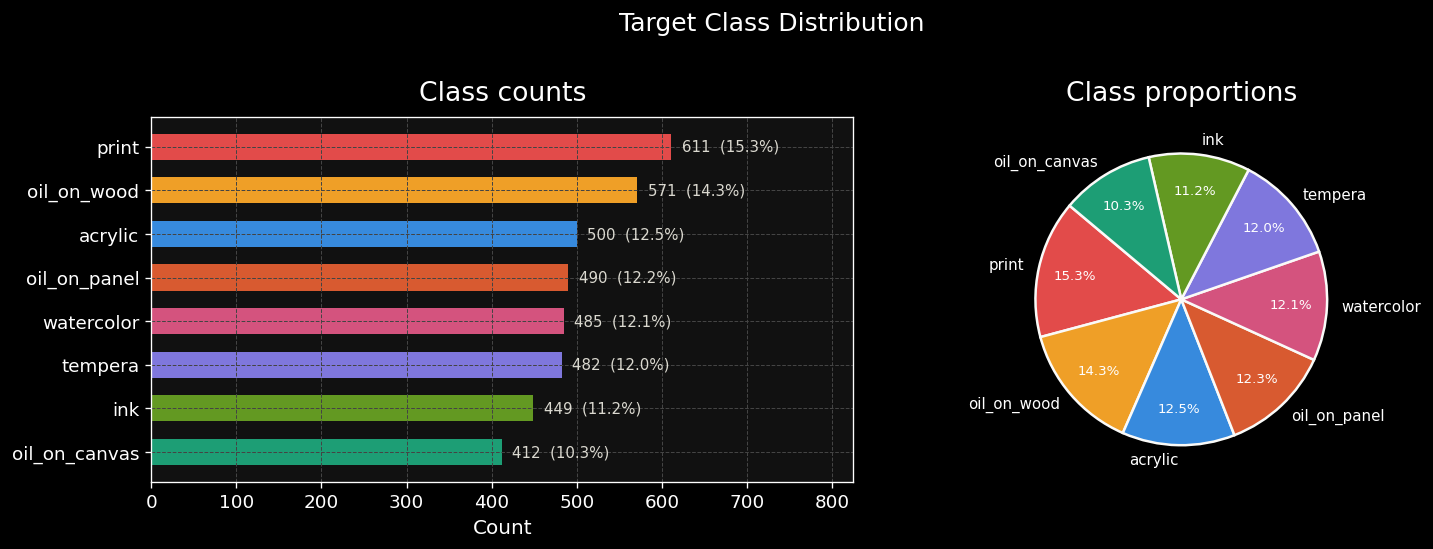

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Target Class Distribution", fontsize=15, fontweight="500", y=1.01)
 
counts = df["y"].map(CLASS_NAMES).value_counts().sort_values(ascending=True)
colors_bar = [PALETTE[list(CLASS_NAMES.values()).index(c)] for c in counts.index]
 
axes[0].barh(counts.index, counts.values, color=colors_bar, height=0.6)
for v, label in zip(counts.values, counts.index):
    axes[0].text(v + 12, label, f"{v:,}  ({v/n*100:.1f}%)", va="center", fontsize=9, color="#DBD9D0")
axes[0].set_xlabel("Count")
axes[0].set_title("Class counts", pad=10)
axes[0].set_xlim(0, counts.max() * 1.35)
 
pct = df["y"].map(CLASS_NAMES).value_counts(normalize=True) * 100
wedge_colors = [PALETTE[list(CLASS_NAMES.values()).index(c)] for c in pct.index]
wedges, texts, autotexts = axes[1].pie(
    pct.values, labels=pct.index, colors=wedge_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 4 else "",
    startangle=140, pctdistance=0.75,
    wedgeprops={"linewidth": 1.5, "edgecolor": "#FAFAF8"}
)
for t in texts: t.set_fontsize(9)
for at in autotexts: at.set_fontsize(8)
axes[1].set_title("Class proportions", pad=10)
 
plt.tight_layout()
plt.show()

## **2. MISSING VALUES DISTRIBUTION**

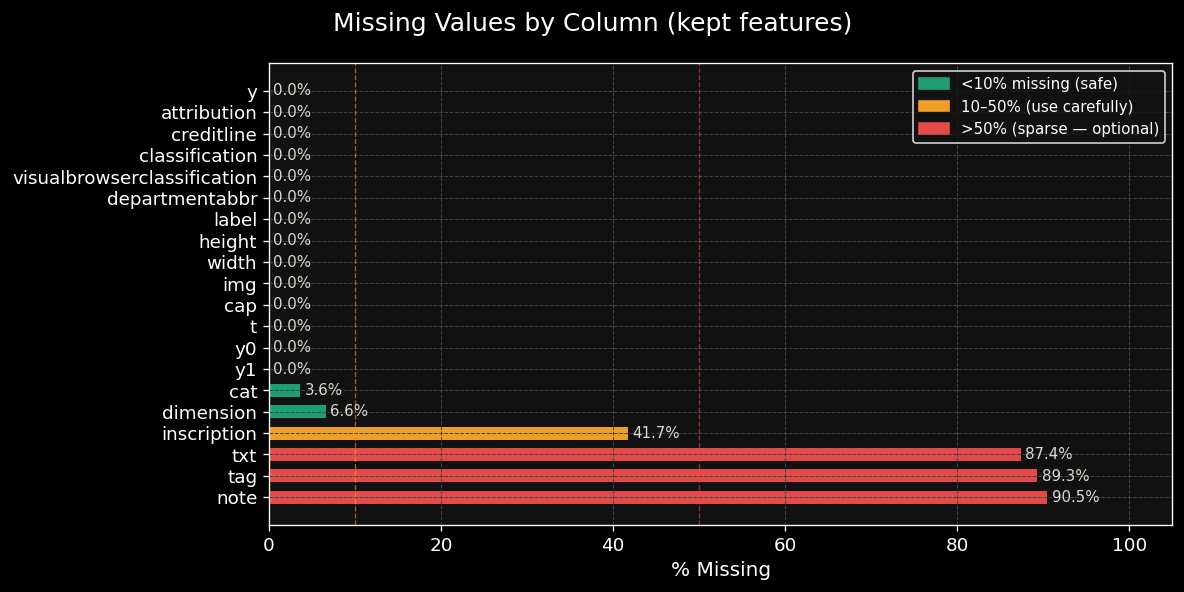

In [148]:
miss = df.isnull().mean() * 100
miss = miss.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Missing Values by Column (kept features)', fontsize=15, fontweight='500')

bar_colors = ["#E24B4A" if v > 50 else "#EF9F27" if v > 10 else "#1D9E75" for v in miss.values]
bars = ax.barh(miss.index, miss.values, color=bar_colors, height=0.6)
for bar, v in zip(bars, miss.values):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, f"{v:.1f}%", va="center", fontsize=9, color="#DBD9D0")

ax.set_xlabel("% Missing")
ax.set_xlim(0, 105)
ax.axvline(50, color="#E24B4A", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(10, color="#EF9F27", linewidth=0.8, linestyle="--", alpha=0.6)
 
patches = [mpatches.Patch(color="#1D9E75", label="<10% missing (safe)"),
           mpatches.Patch(color="#EF9F27", label="10–50% (use carefully)"),
           mpatches.Patch(color="#E24B4A", label=">50% (sparse — optional)")]

ax.legend(handles=patches, fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

## **3. YEAR DISTRIBUTION BY CLASS**

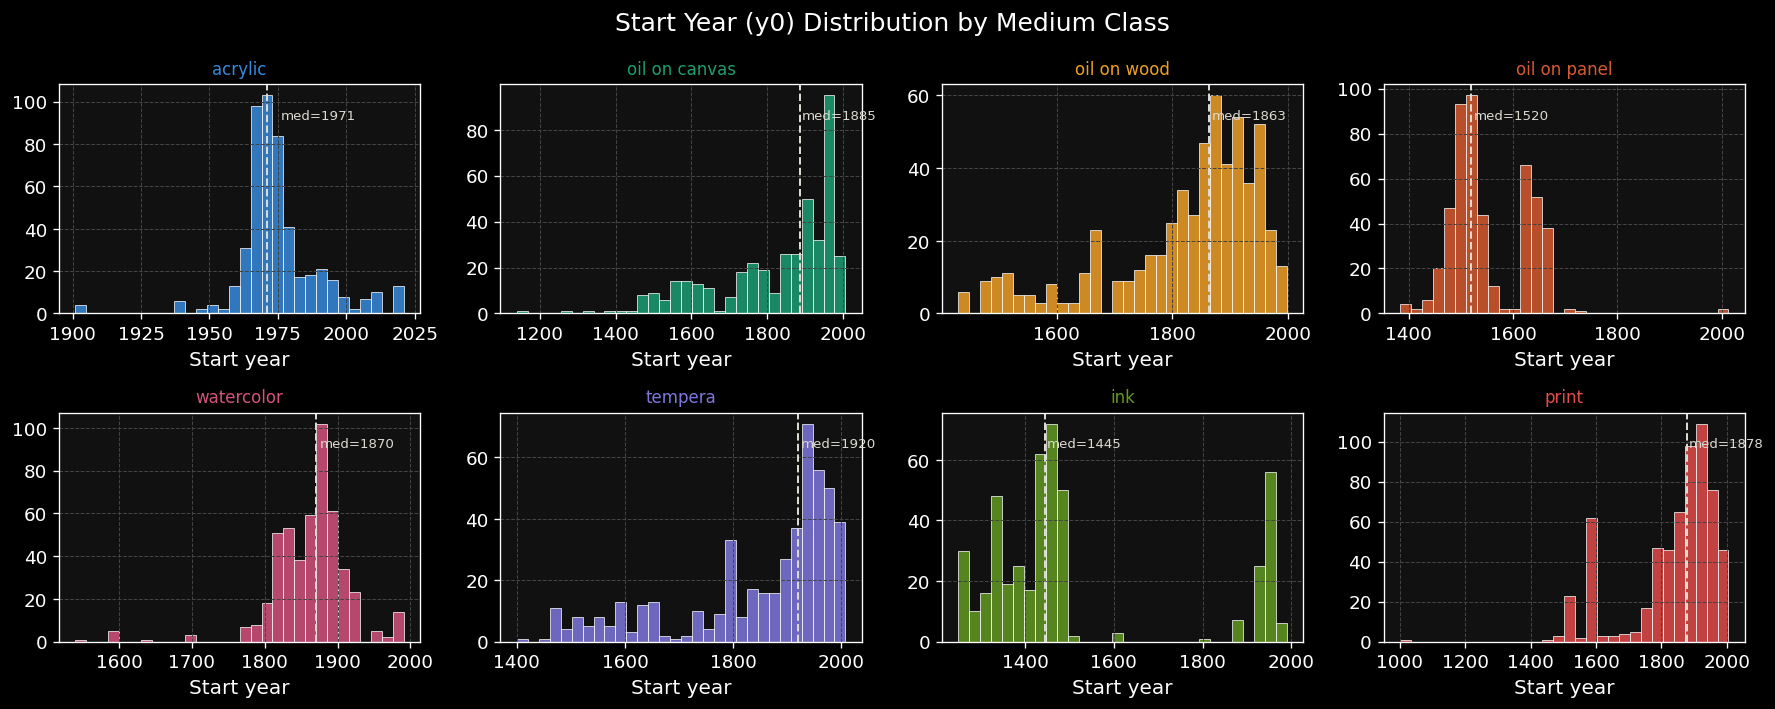

In [149]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharey=False)
fig.suptitle("Start Year (y0) Distribution by Medium Class", fontsize=15, fontweight="500")
axes = axes.flatten()
 
for i, (cls_id, cls_name) in enumerate(CLASS_NAMES.items()):
    sub = df[df["y"] == cls_id]["y0"].dropna()
    axes[i].hist(sub, bins=30, color=PALETTE[i], alpha=0.85, edgecolor="white", linewidth=0.5)
    axes[i].set_title(cls_name.replace("_", " "), fontsize=10, color=PALETTE[i], fontweight="500")
    axes[i].set_xlabel("Start year")
    med = sub.median()
    axes[i].axvline(med, color="#DBD9D0", linewidth=1.2, linestyle="--")
    axes[i].text(med+5, axes[i].get_ylim()[1]*0.85, f"med={int(med)}", fontsize=8, color="#DBD9D0")
 
plt.tight_layout()
plt.show()

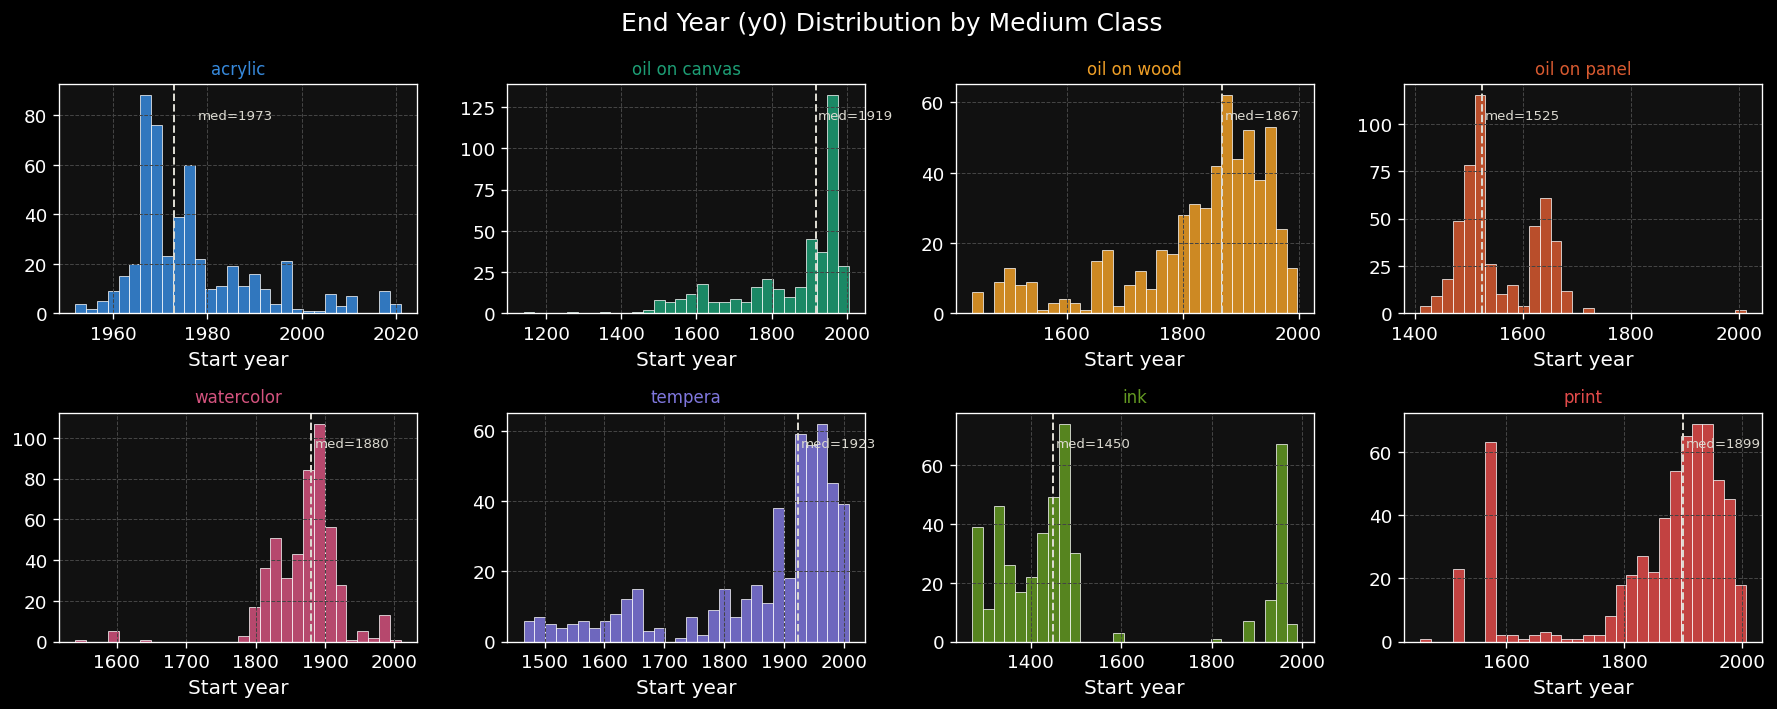

In [150]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharey=False)
fig.suptitle("End Year (y0) Distribution by Medium Class", fontsize=15, fontweight="500")
axes = axes.flatten()
 
for i, (cls_id, cls_name) in enumerate(CLASS_NAMES.items()):
    sub = df[df["y"] == cls_id]["y1"].dropna()
    axes[i].hist(sub, bins=30, color=PALETTE[i], alpha=0.85, edgecolor="white", linewidth=0.5)
    axes[i].set_title(cls_name.replace("_", " "), fontsize=10, color=PALETTE[i], fontweight="500")
    axes[i].set_xlabel("Start year")
    med = sub.median()
    axes[i].axvline(med, color="#DBD9D0", linewidth=1.2, linestyle="--")
    axes[i].text(med+5, axes[i].get_ylim()[1]*0.85, f"med={int(med)}", fontsize=8, color="#DBD9D0")
 
plt.tight_layout()
plt.show()

## **4. NUMERIC FEATURES — BOXPLOTS BY CLASS**

In [151]:
handle_missing(df)

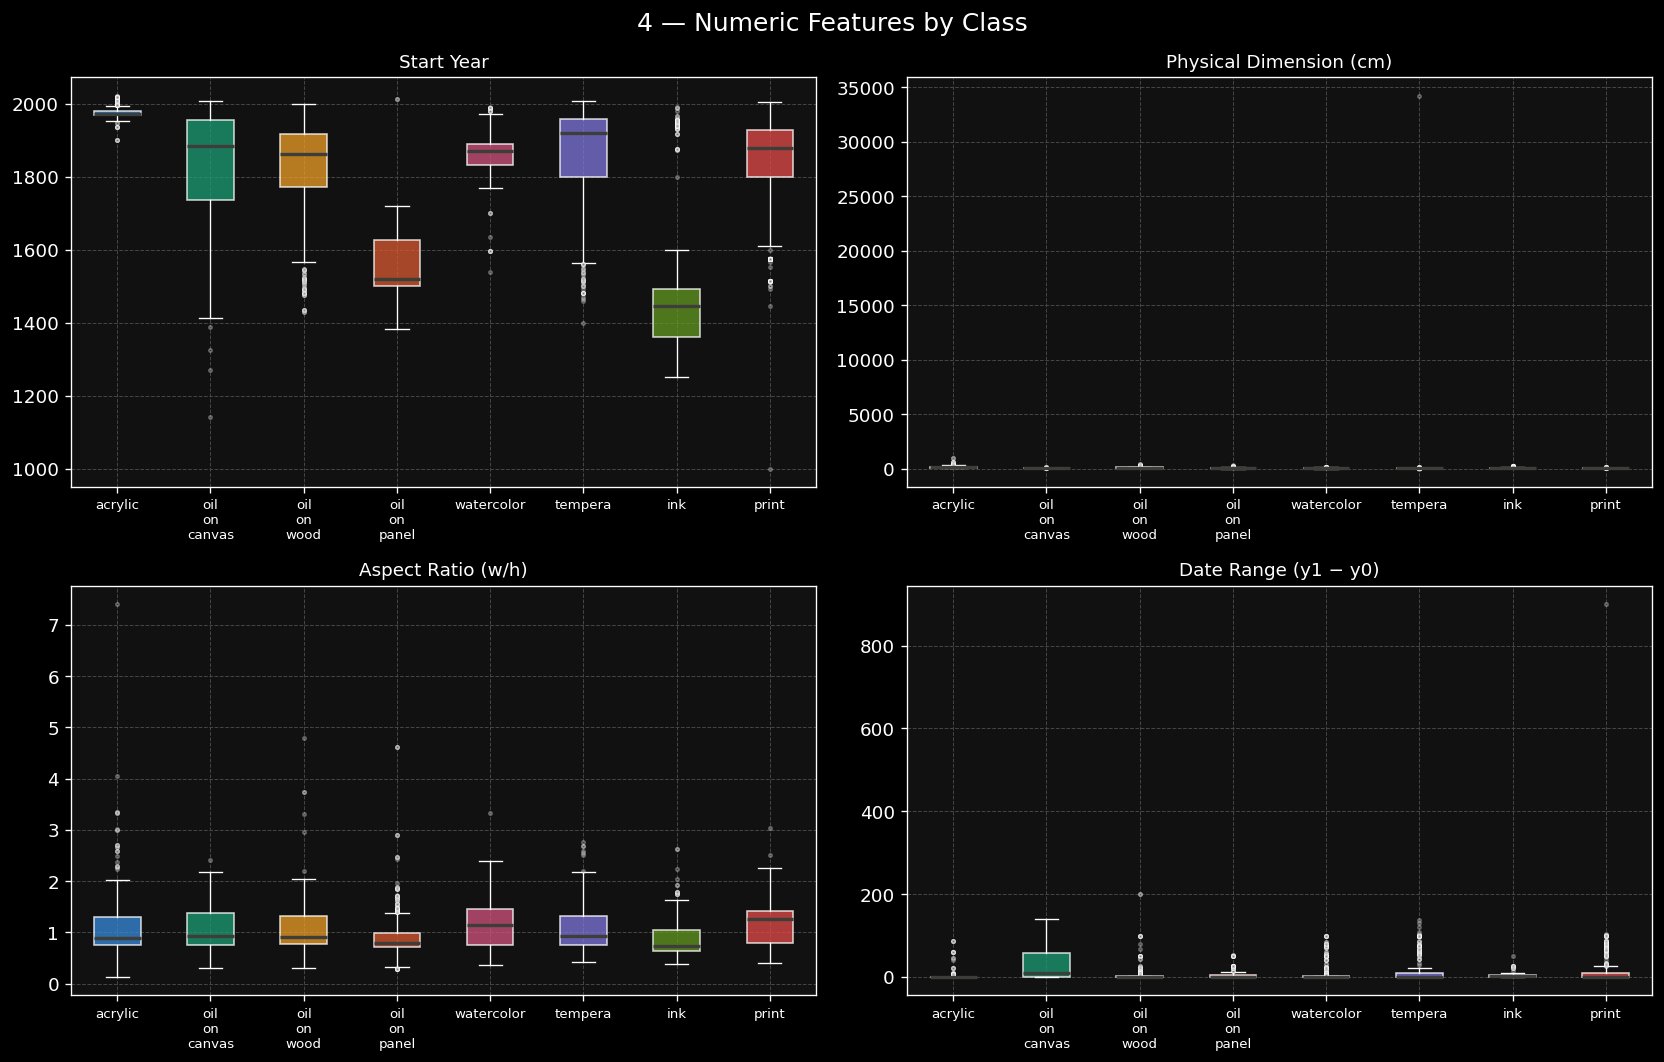

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Numeric Features by Class", fontsize=15, fontweight="500")
 
numeric_features = [
    ("y0", "Start Year"),
    ("dimension", "Physical Dimension (cm)"),
    ("aspect_ratio", "Aspect Ratio (w/h)"),
    ("date_range", "Date Range (y1 − y0)"),
]
order = list(CLASS_NAMES.values())
 
for ax, (col, title) in zip(axes.flatten(), numeric_features):
    data_by_class = [df[df["y"]==k][col].dropna().values for k in CLASS_NAMES.keys()]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                    medianprops={"color":"#3D3D3A","linewidth":2},
                    whiskerprops={"linewidth":0.8},
                    capprops={"linewidth":0.8},
                    flierprops={"marker":"o","markersize":2,"alpha":0.3,"markerfacecolor":"gray"})
    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels([n.replace("_on_","\non\n") for n in order], fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
 
plt.tight_layout()
plt.show()

## **5. CATEGORICAL FEATURE DISTRIBUTION**

In [156]:
df["y_label"] = df["y"].map(CLASS_NAMES)

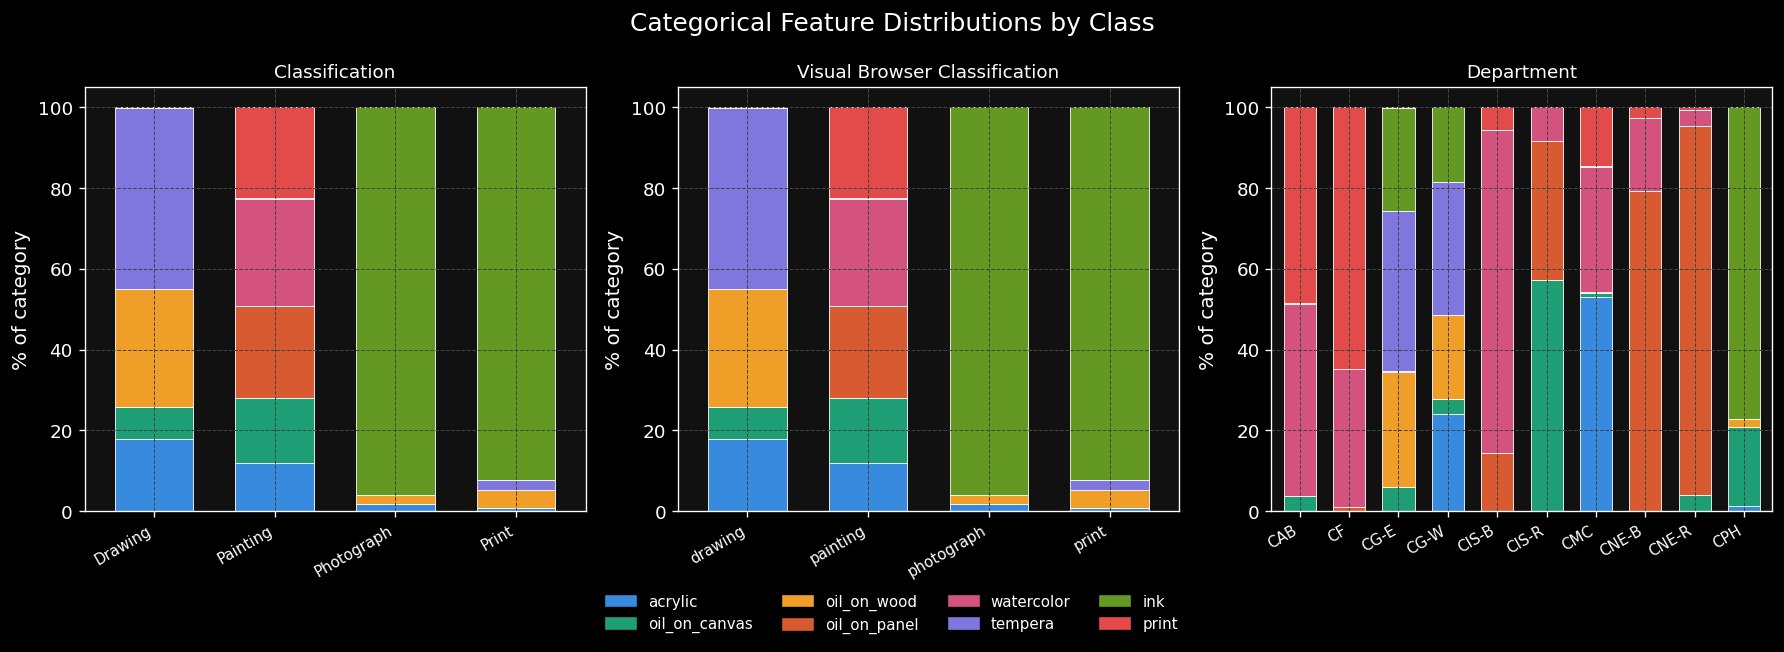

In [158]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Categorical Feature Distributions by Class", fontsize=15, fontweight="500")
 
cat_features = [
    ("classification", "Classification"),
    ("visualbrowserclassification", "Visual Browser Classification"),
    ("departmentabbr", "Department"),
]
 
for ax, (col, title) in zip(axes, cat_features):
    ct = pd.crosstab(df[col], df["y_label"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, color=PALETTE[:len(CLASS_NAMES)],
            width=0.65, edgecolor="white", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("% of category")
    ax.legend_.remove()
 
handles = [mpatches.Patch(color=PALETTE[i], label=CLASS_NAMES[i]) for i in range(len(CLASS_NAMES))]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.tight_layout()
plt.show()

## **6. HEATMAP**

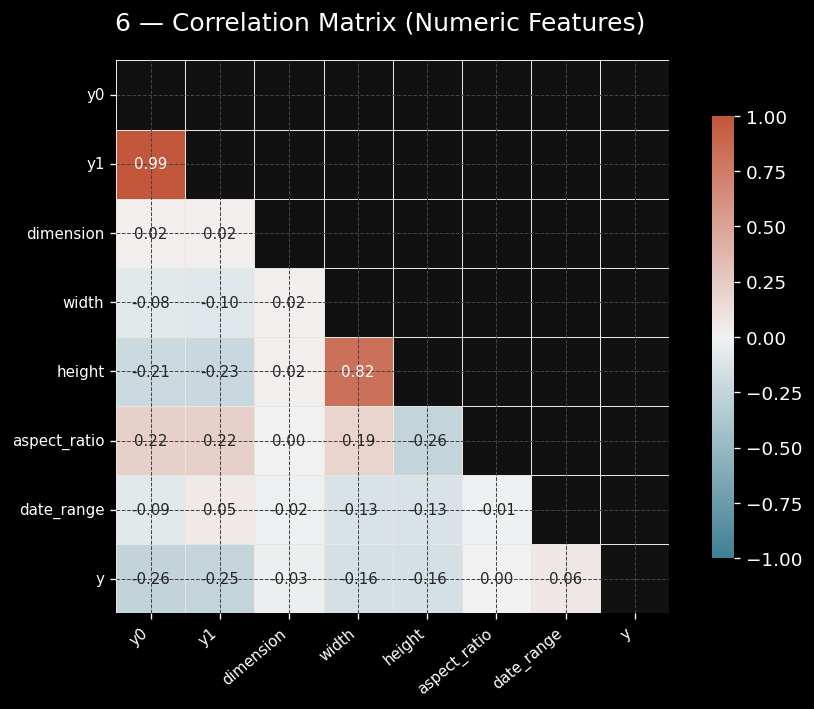

In [160]:
numeric_cols = ["y0","y1","dimension","width","height","aspect_ratio","date_range","y"]
corr = df[numeric_cols].corr()
 
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("6 — Correlation Matrix (Numeric Features)", fontsize=15, fontweight="500")
 
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.5, linecolor="#E8E6DE",
            ax=ax, annot_kws={"size": 9}, square=True,
            cbar_kws={"shrink": 0.8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## **7. TEXT FEATURE (CAP LENGTH & WORD COUNT)**

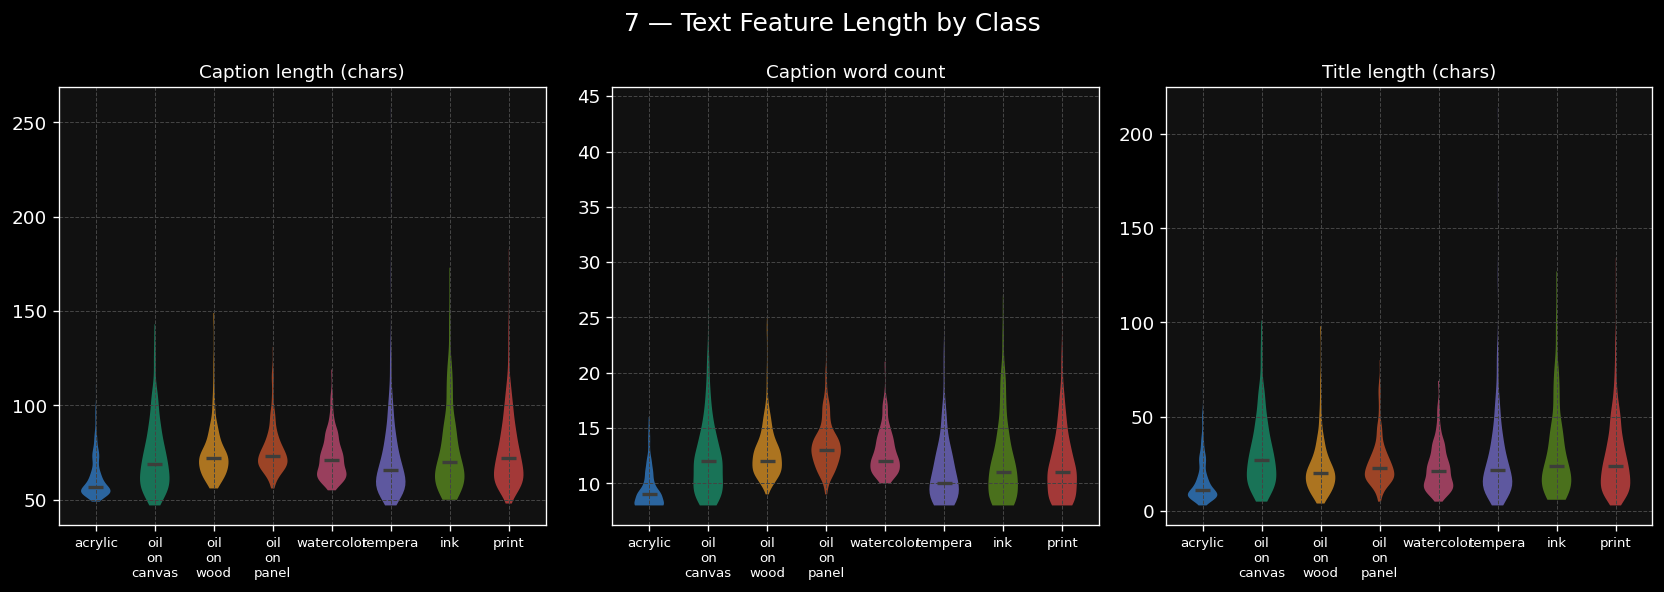

In [ ]:
df["cap_len"]   = df["cap"].fillna("").str.len()
df["cap_words"] = df["cap"].fillna("").str.split().str.len()
df["t_len"]     = df["t"].fillna("").str.len()
 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(" Text Feature Length by Class", fontsize=15, fontweight="500")
 
for ax, (col, title) in zip(axes, [
    ("cap_len",   "Caption length (chars)"),
    ("cap_words", "Caption word count"),
    ("t_len",     "Title length (chars)"),
]):
    data = [df[df["y"]==k][col].values for k in CLASS_NAMES.keys()]
    vp = ax.violinplot(data, positions=range(len(CLASS_NAMES)),
                       showmedians=True, showextrema=False)
    for i, (body, color) in enumerate(zip(vp["bodies"], PALETTE)):
        body.set_facecolor(color); body.set_alpha(0.7)
    vp["cmedians"].set_color("#3D3D3A"); vp["cmedians"].set_linewidth(2)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels([CLASS_NAMES[k].replace("_on_","\non\n") for k in CLASS_NAMES], fontsize=8)
    ax.set_title(title, fontsize=11)
 
plt.tight_layout()
plt.show()

## **8. TEMPORAL TREND — CLASS PROPORTIONS OVER CENTURIES**

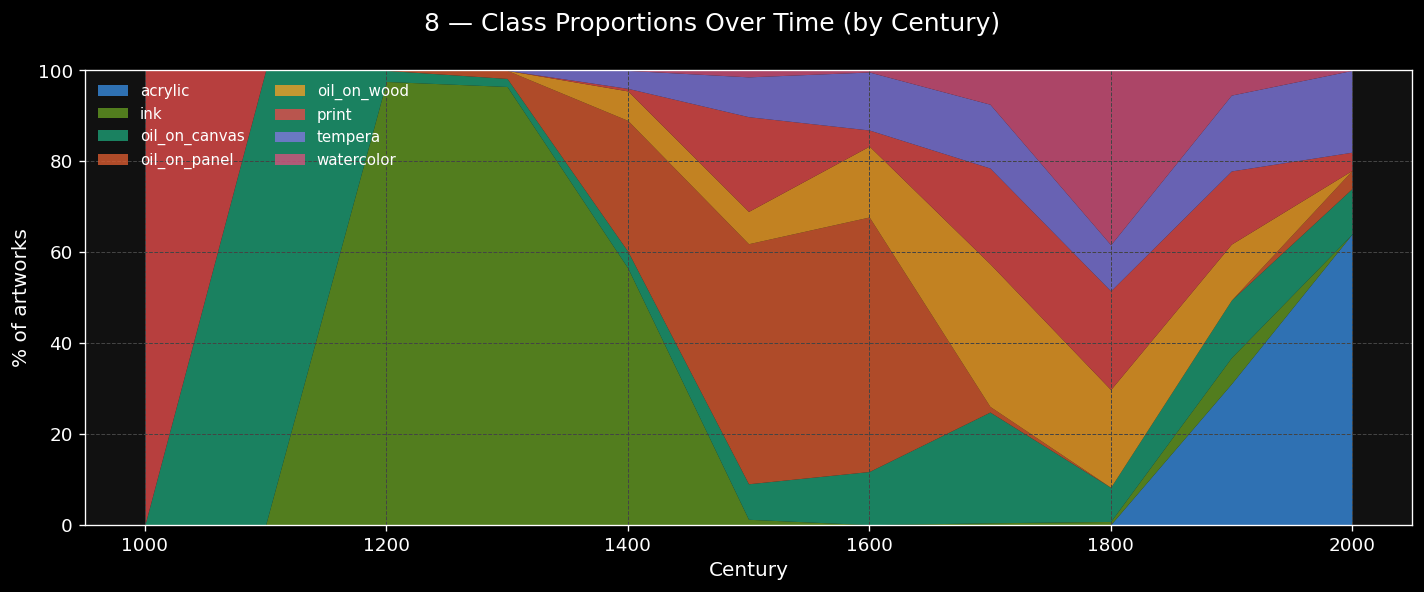

In [ ]:
df["century"] = (df["y0"] // 100 * 100).astype("Int64")
century_class = df.groupby(["century","y_label"]).size().unstack(fill_value=0)
century_class_pct = century_class.div(century_class.sum(axis=1), axis=0) * 100
 
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Class Proportions Over Time (by Century)", fontsize=15, fontweight="500")
 
century_class_pct.plot(kind="area", stacked=True, ax=ax,
                       color=[PALETTE[list(CLASS_NAMES.values()).index(c)]
                              for c in century_class_pct.columns],
                       alpha=0.8, linewidth=0)
ax.set_xlabel("Century")
ax.set_ylabel("% of artworks")
ax.set_ylim(0, 100)
ax.legend(loc="upper left", fontsize=9, ncol=2, frameon=False)
plt.tight_layout()
plt.show()

## **9. DIMENTION SCATTER**

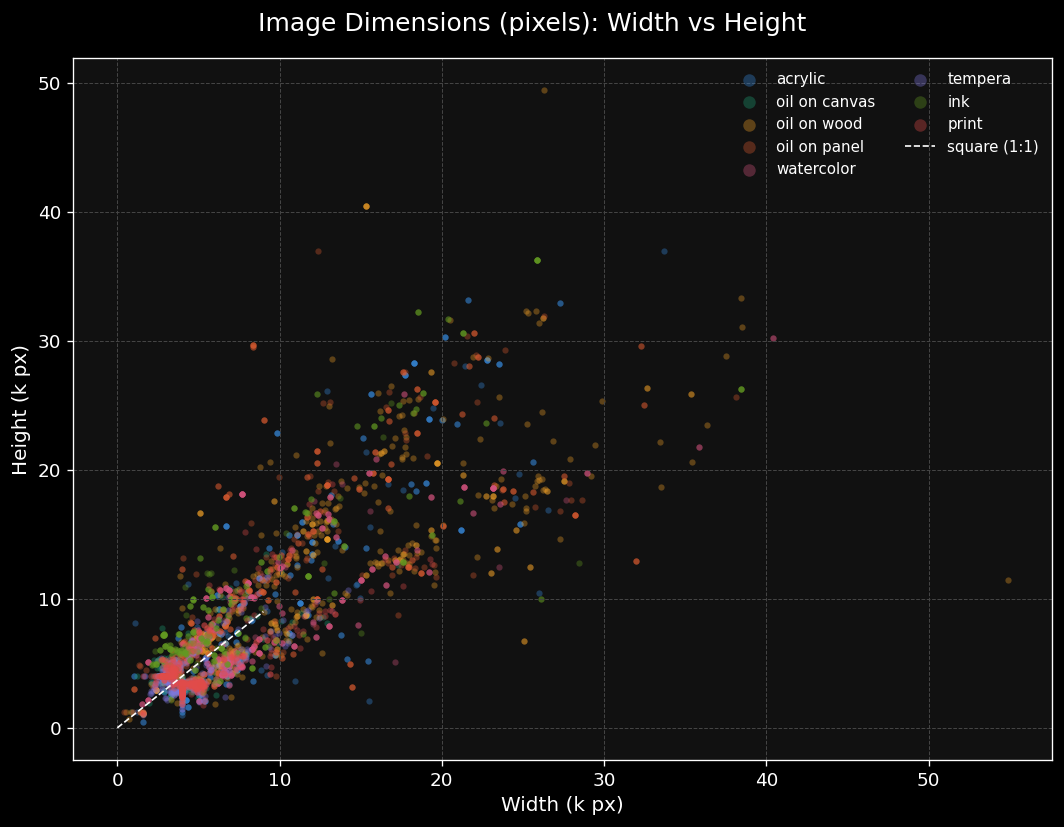

In [167]:
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("Image Dimensions (pixels): Width vs Height", fontsize=15, fontweight="500")
 
for cls_id, cls_name in CLASS_NAMES.items():
    sub = df[df["y"] == cls_id]
    ax.scatter(sub["width"]/1000, sub["height"]/1000,
               label=cls_name.replace("_"," "), color=PALETTE[cls_id],
               alpha=0.35, s=14, linewidths=0)
 
ax.plot([0, 9], [0, 9], "--", color="#FFFFFF", linewidth=1, label="square (1:1)")
ax.set_xlabel("Width (k px)")
ax.set_ylabel("Height (k px)")
ax.legend(fontsize=9, ncol=2, frameon=False, markerscale=2)
plt.tight_layout()
plt.show()

In [171]:
print("\n" + "="*60)
print("EDA SUMMARY — KEY FINDINGS")
print("="*60)
print(f"\n{'Class':<20} {'N':>6} {'%':>7} {'Median Year':>13} {'Median Dim':>12}")
print("-"*63)
for k, name in CLASS_NAMES.items():
    sub = df[df["y"]==k]
    print(f"{name:<20} {len(sub):>6} {len(sub)/n*100:>6.1f}% "
          f"{sub['y0'].median():>13.0f} "
          f"{sub['dimension'].median():>11.1f}cm")
 
print("\nImbalance ratio:", round(df["y"].value_counts().max() / df["y"].value_counts().min(), 1), "x")
print("Year range:", int(df["y0"].min()), "–", int(df["y0"].max()))
print("Avg aspect ratio:", round(df["aspect_ratio"].mean(), 2))


EDA SUMMARY — KEY FINDINGS

Class                     N       %   Median Year   Median Dim
---------------------------------------------------------------
acrylic                 500   12.5%          1971       101.6cm
oil_on_canvas           412   10.3%          1884        27.8cm
oil_on_wood             571   14.3%          1863        75.5cm
oil_on_panel            490   12.2%          1520        45.6cm
watercolor              485   12.1%          1870        39.3cm
tempera                 482   12.0%          1920        23.9cm
ink                     449   11.2%          1445        46.4cm
print                   611   15.3%          1878        29.4cm

Imbalance ratio: 1.5 x
Year range: 1000 – 2021
Avg aspect ratio: 1.05
